# Sleep Cannabis Alcohol Study

- Merging merged actigraphy data from the 4 studies with the scored (scrubbed) actigraphy data from each study

Notes: 
- Use scored data for start and stop times.
- Use the actigraphy data for determining sleep metrics
- Calculate sleep biomarkers for: 
  1. sleep onset to sleep offset (lets me verify data outputs compared to orignal scored dataset)
  2. First 1/2 of sleep night i.e., start sleep to mid-sleep)
  3. first 4-h of sleep (sleep start to sleep start + 4h)

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

#### Actigraphy Data

In [2]:
## Upload csv containing all epoch-by-epoch actigraph data from participants in each of the 4 studies (DXA, Siesta2, SNA, SPU)
## from Jupyter notebook titled RUSleep_alcohol_actigraphy_uploads
actigraphy_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/Data_analysis/full_actigraphy_df_cleaned_09.16.26.csv', index_col=0, dtype={'date':str, 'time':str})

actigraphy_df.head()

,subject_id,study,date,time,time_epoch,date_time24,off_wrist_status,activity,marker,sleep/wake,interval_status,participant
0,DXA_174,DXA,3/27/2025,12:49:00 PM,769,2025-03-27 12:49:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
1,DXA_174,DXA,3/27/2025,12:50:00 PM,770,2025-03-27 12:50:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
2,DXA_174,DXA,3/27/2025,12:51:00 PM,771,2025-03-27 12:51:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
3,DXA_174,DXA,3/27/2025,12:52:00 PM,772,2025-03-27 12:52:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
4,DXA_174,DXA,3/27/2025,12:53:00 PM,773,2025-03-27 12:53:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah


In [3]:
actigraphy_df['subject_id'].nunique()
## n=256 from actigraphy files
## check/drop DXA_118, Siesta2_106, Siesta2_112, Siesta2_233, Siesta2_381 for low actigraphy compliance

256

In [4]:
## convert dtypes for analysis
actigraphy_df['subject_id'] = actigraphy_df['subject_id'].astype(str)
actigraphy_df['subject_id'] = actigraphy_df['subject_id'].replace('SNA1', 'SNA').replace('SPU1', 'SPU')
actigraphy_df['study'] = actigraphy_df['study'].replace('SNA1', 'SNA').replace('SPU1', 'SPU')
actigraphy_df['date_time24'] = pd.to_datetime(actigraphy_df['date'] + ' ' + actigraphy_df['time'], format='mixed')

actigraphy_df.head()

,subject_id,study,date,time,time_epoch,date_time24,off_wrist_status,activity,marker,sleep/wake,interval_status,participant
0,DXA_174,DXA,3/27/2025,12:49:00 PM,769,2025-03-27 12:49:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
1,DXA_174,DXA,3/27/2025,12:50:00 PM,770,2025-03-27 12:50:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
2,DXA_174,DXA,3/27/2025,12:51:00 PM,771,2025-03-27 12:51:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
3,DXA_174,DXA,3/27/2025,12:52:00 PM,772,2025-03-27 12:52:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
4,DXA_174,DXA,3/27/2025,12:53:00 PM,773,2025-03-27 12:53:00,0,NaN,0.0,NaN,ACTIVE,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah


In [5]:
actigraphy_codes = actigraphy_df['subject_id'].unique()
## Isolate subject_id values from all participants with uploaded actigraphy files
actigraphy_codes_df = pd.DataFrame({
    'subject_id':actigraphy_codes
})
## add other relevant columns for identifying participants from their respective study and actigraphy file names
actigraphy_codes_df_clean = pd.merge(actigraphy_codes_df, actigraphy_df[['subject_id', 'study', 'participant']].drop_duplicates('subject_id'), how='left', on='subject_id'
)
actigraphy_codes_df_clean['subject_id'] = actigraphy_codes_df_clean['subject_id'].str.strip()

# actigraphy_codes_df
actigraphy_codes_df_clean.head()

## This dataframe now has subject_id and study and actigraph file values for each actigraph file uploaded into the actigraphy_df
## Use this to help figure out who from the compliant (n=251) and passcode (n=259) dfs should remain for further analysis. 

,subject_id,study,participant
0,DXA_174,DXA,dxa174_3_27_2025_12_49_00_pm_174_24hr_ah
1,DXA_022,DXA,dxa022_10_31_2019_1_56_00_pm_cc_24hr_combined
2,DXA_025,DXA,dxa025_11_5_2019_2_34_00_pm_cc_24hr_combined
3,DXA_110,DXA,dxa110_10_31_2023_1_23_00_pm_cc_24hr_combined
4,DXA_002,DXA,dxa002_9_24_2019_10_04_00_am_cc_24hr_combined


### Import passcode-subject_id code list

- This is used to map passcodes and subject_ids from both the epoch-by-epoch actigraph files and the old/new scored sleep summary data dfs

In [6]:
## Passcodes_df was originally created from scored sleep summary datasets from each of the four individual studies (DXA, Siesta2, SPU, SNA)
passcodes_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/scored_summary_actigraphy_data/passcode_study_df_091626.xlsx', index_col=0)

passcodes_df['subject_id'] = passcodes_df['subject_id'].replace(r'1_','_', regex=True).str.strip().astype(str)
# passcodes_df['subject_id'] = passcodes_df['subject_id'].replace('SNA1', 'SNA').replace('SPU1', 'SPU')
passcodes_df['passcode'] = passcodes_df['passcode'].astype(str)

passcodes_df.head()

,subject_id,passcode,study
0,SNA_154801,Lynn,SNA
1,SNA_154804,Bergen,SNA
2,SNA_154808,Serra,SNA
3,SNA_154809,Salavan,SNA
4,SNA_154810,Preston,SNA


In [7]:
## Check participant counts between actigraphy files and original passcode_df
passcode_id_count = (passcodes_df['subject_id'].nunique())
actigraphy_id_count = (actigraphy_df['subject_id'].nunique())

print(f'There are {actigraphy_id_count} individual participants included in all individual actigraphy files and {passcode_id_count} in the passcode_df')

## see what subject_id values from passcodes are not in (merged) actigraphy_df 
passcodes_no_actigraphy = passcodes_df[~passcodes_df['subject_id'].isin(actigraphy_df['subject_id'].values)]
## see what subject_id values from actigraphy_df are not in the passcodes list
actigraphy_no_passcodes = actigraphy_df[~actigraphy_df['subject_id'].isin(passcodes_df['subject_id'].values)]

print(f'{passcodes_no_actigraphy['subject_id'].values} are not in raw actigraphy files but in (old) scored sleep files')
print(f'{actigraphy_no_passcodes['subject_id'].values} have actigraph files but are not in passcodes')
## DXA_005 has 6 of 13 nights of sleep data (excluded)
## DXA_105 has 5 of 6 nights of sleep data collected (excluded for insufficient # of nights)
## DXA_128 has 6 of 7 nights of sleep data collected (excluded for insufficient # of nights)

## Excluding these 3 participants has been verified 9/17/26 (keep them out).

There are 256 individual participants included in all individual actigraphy files and 259 in the passcode_df
['DXA_005' 'DXA_105' 'DXA_128'] are not in raw actigraphy files but in (old) scored sleep files
[] have actigraph files but are not in passcodes


## Create master code list

In [8]:
master_code_df = pd.merge(actigraphy_codes_df_clean, passcodes_df, how='left', on=['subject_id', 'study']
)
master_code_df['passcode'] = master_code_df['passcode'].str.strip()
## Use this for determining what participants are in actigraphy data (individual actigraph files) and who are in compliant scored sleep summary datasets.

### Import updated compliant scored sleep data

In [9]:
## Import updated compliant scored sleep data (n=251)
scored_sleep_compliant_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/scored_summary_actigraphy_data/AllStudies_Diary_Actigraphy_SleepTiming_COMPLIANT.xlsx')
## tidy up columns for consistency
scored_sleep_compliant_df.columns = scored_sleep_compliant_df.columns.str.strip().str.replace(' ', '_').str.lower()
scored_sleep_compliant_df.rename(columns={'subjectid':'old_subject_id'}, inplace=True)
scored_sleep_compliant_df['passcode'] = scored_sleep_compliant_df['passcode'].replace(r'^Si', '', regex=True).str.strip()
## manually fix a passcode that was messed up below due to the regex expression
scored_sleep_compliant_df['passcode'] = scored_sleep_compliant_df['passcode'].replace('don', 'Sidon')
scored_sleep_compliant_df['passcode'] = scored_sleep_compliant_df['passcode'].astype(str)

scored_sleep_compliant_df.head()

,old_subject_id,passcode,studyday,start_date,start_day,start_time,end_date,end_day,end_time,start_date_nondst,...,midpoint_timing,midpoint_time,date,night,timetosleep,sleepquality,sleepinessscale,alcohol,marijuana,alcohol_amount
0,1,DXA001,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,07:56:00,2019-09-20,...,218.5,03:38:30,2019-09-20,Friday,20.0,2.0,7.0,0.0,0.0,NaN
1,1,DXA001,2,NaT,NaN,NaN,NaT,NaN,NaN,NaT,...,NaN,NaN,2019-09-21,Saturday,10.0,4.0,3.0,0.0,0.0,NaN
2,1,DXA001,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,08:30:00,2019-09-22,...,186.0,03:06:00,2019-09-22,Sunday,5.0,2.0,6.0,0.0,0.0,NaN
3,1,DXA001,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,07:49:00,2019-09-23,...,185.0,03:05:00,2019-09-23,Monday,40.0,2.0,7.0,0.0,0.0,NaN
4,1,DXA001,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,08:20:00,2019-09-25,...,264.5,04:24:30,2019-09-24,Tuesday,30.0,1.0,4.0,0.0,0.0,NaN


### Vet compliant scored sleep participants against master code list

In [10]:
master_id_count = (master_code_df['subject_id'].nunique())
compliant_passcode_count = (scored_sleep_compliant_df['passcode'].nunique())

print(f'There are {master_id_count} individual participants included in all individual actigraphy files and {compliant_passcode_count} in the compliant_scored_sleep_df')


There are 256 individual participants included in all individual actigraphy files and 251 in the compliant_scored_sleep_df


In [11]:
compliant_min_master = set(scored_sleep_compliant_df['passcode'].values) - set(master_code_df['passcode'].values)

print(f'{compliant_min_master} in compliant list and not in master')
## This is good

set() in compliant list and not in master


In [12]:
master_code_min_compliant = set(master_code_df['passcode'].values) - set(scored_sleep_compliant_df['passcode'].values)

print([f'{master_code_min_compliant} are in master list and not in compliant'])

## this matches what Kelly S. was mentioning...These five participants have actigraph data but were non-compliant (exclude from analysis).

["{'DXA118', '381', '106', '233', '112'} are in master list and not in compliant"]


In [13]:
master_compliant_scored_sleep_df = pd.merge(scored_sleep_compliant_df, master_code_df, how='left', on='passcode')
# master_compliant_scored_sleep_df['subject_id'].nunique()
## n=251, same as compliant list pre-merge

first_cols = ['subject_id', 'passcode', 'study', 'old_subject_id']
remaining_cols = [col for col in master_compliant_scored_sleep_df.columns if col not in first_cols]
## reorder columns
master_compliant_scored_sleep_df_cleaned = master_compliant_scored_sleep_df[first_cols + remaining_cols]

master_compliant_scored_sleep_df_cleaned.head()

,subject_id,passcode,study,old_subject_id,studyday,start_date,start_day,start_time,end_date,end_day,...,midpoint_time,date,night,timetosleep,sleepquality,sleepinessscale,alcohol,marijuana,alcohol_amount,participant
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,03:38:30,2019-09-20,Friday,20.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
1,DXA_001,DXA001,DXA,1,2,NaT,NaN,NaN,NaT,NaN,...,NaN,2019-09-21,Saturday,10.0,4.0,3.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
2,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,03:06:00,2019-09-22,Sunday,5.0,2.0,6.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
3,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,03:05:00,2019-09-23,Monday,40.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
4,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,04:24:30,2019-09-24,Tuesday,30.0,1.0,4.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined


### Finalize master_code_list

In [14]:
first_cols = ['subject_id', 'passcode', 'study', 'old_subject_id']
remaining_cols = [col for col in master_compliant_scored_sleep_df.columns if col not in first_cols]
## reorder columns
master_compliant_scored_sleep_df_cleaned = master_compliant_scored_sleep_df[first_cols + remaining_cols]

master_compliant_scored_sleep_df_cleaned.head()

,subject_id,passcode,study,old_subject_id,studyday,start_date,start_day,start_time,end_date,end_day,...,midpoint_time,date,night,timetosleep,sleepquality,sleepinessscale,alcohol,marijuana,alcohol_amount,participant
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,03:38:30,2019-09-20,Friday,20.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
1,DXA_001,DXA001,DXA,1,2,NaT,NaN,NaN,NaT,NaN,...,NaN,2019-09-21,Saturday,10.0,4.0,3.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
2,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,03:06:00,2019-09-22,Sunday,5.0,2.0,6.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
3,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,03:05:00,2019-09-23,Monday,40.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
4,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,04:24:30,2019-09-24,Tuesday,30.0,1.0,4.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined


In [15]:
### Create master list for cross-referencing different datasets (sleep & alcohol)
master_compliant_id_list = master_compliant_scored_sleep_df_cleaned['subject_id'].unique()
master_codes = pd.DataFrame({'subject_id': master_compliant_id_list})

master_codes_df = pd.merge(master_codes, master_compliant_scored_sleep_df_cleaned[['subject_id', 'study', 'participant', 'passcode']].drop_duplicates('subject_id'), how='left', on='subject_id')
## set column order preferences
col_order = ['subject_id','passcode', 'study', 'participant']
master_codes_df = master_codes_df[col_order]

master_codes_df.to_excel('master_codes_df_091726.xlsx') ## export for verifying with other researchers (and for reference)
master_codes_df
## so far, looks good.

,subject_id,passcode,study,participant
0,DXA_001,DXA001,DXA,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
1,DXA_002,DXA002,DXA,dxa002_9_24_2019_10_04_00_am_cc_24hr_combined
2,DXA_003,DXA003,DXA,dxa003_(withdrawn)_9_24_2019_2_09_00_pm_003_24...
3,DXA_004,DXA004,DXA,dxa004_9_26_2019_9_48_00_am_cc_24hr_combined
4,DXA_008,DXA008,DXA,dxa008_10_15_2019_12_10_00_pm_cc_24hr_combined
...,...,...,...,...
246,SNA_154847,Kassala,SNA,sna154847_12_1_2025_1_57_00_pm_sna154847_24hr_ks
247,SNA_154848,Carmen,SNA,sna154848_11_25_2025_9_53_00_am_sna154848_24hr_ks
248,SNA_154850,Nazareth,SNA,sna154850_3_25_2026_2_58_00_pm_sna154850_24hr_ks
249,SNA_154853,Chengdu,SNA,sna154853_3_31_2026_5_00_00_pm_sna154853_24hr_ks


In [16]:
master_compliant_scored_sleep_df_cleaned.to_excel('master_compliant_scored_sleep_df_cleaned_09.17.26.xlsx')

In [17]:
# master_compliant_scored_sleep_df.head()

In [18]:
# master_compliant_scored_sleep_df_cleaned.head()

In [19]:
## checking spread (min of 7 nights for inclusion in study)
count_sorted = (master_compliant_scored_sleep_df_cleaned.groupby('subject_id').size().reset_index(name='repeat_measures')).sort_values('repeat_measures')

count_sorted
# count_sorted.to_excel('count_of_repeat_measures.xlsx')

,subject_id,repeat_measures
125,SPU_154090,7
107,SNA_154838,7
112,SNA_154845,7
113,SNA_154847,7
117,SNA_154854,7
...,...,...
242,siesta2_275,22
6,DXA_011,22
76,DXA_174,22
233,siesta2_224,23


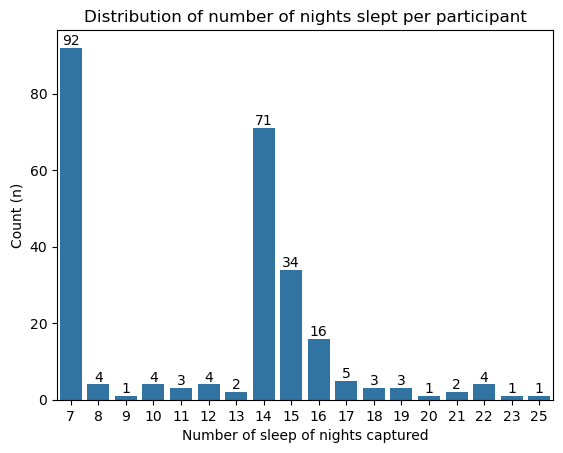

In [20]:
ax = sns.countplot(data=count_sorted, x='repeat_measures')
ax.bar_label(ax.containers[0]
             )
plt.xlabel('Number of sleep of nights captured')
plt.ylabel('Count (n)')
plt.title('Distribution of number of nights slept per participant')

plt.savefig('sleep nights distribution.png')

plt.show()

### Revised Scored Sleep Data (compliant and non-compliant)

In [21]:
# scored_test = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/scored_summary_actigraphy_data/AllStudies_Diary_Actigraphy_SleepTiming_ALL.xlsx')

# scored_test.columns = scored_test.columns.str.lower().str.strip().str.replace(' ', '_')
# scored_test.rename(columns={'subjectid': 'old_subject_id'}, inplace=True)
# scored_test['passcode'] = scored_test['passcode'].replace(r'^Si', '', regex=True)

# scored_test.head()

In [22]:
# all_merged_scored_sleep_df = passcodes_df.merge(scored_test, how = 'left', on='passcode')

# all_merged_scored_sleep_df.head()

In [23]:
scored_sleep_df_cleaned = master_compliant_scored_sleep_df_cleaned.copy()

scored_sleep_df_cleaned.head()

,subject_id,passcode,study,old_subject_id,studyday,start_date,start_day,start_time,end_date,end_day,...,midpoint_time,date,night,timetosleep,sleepquality,sleepinessscale,alcohol,marijuana,alcohol_amount,participant
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,03:38:30,2019-09-20,Friday,20.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
1,DXA_001,DXA001,DXA,1,2,NaT,NaN,NaN,NaT,NaN,...,NaN,2019-09-21,Saturday,10.0,4.0,3.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
2,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,03:06:00,2019-09-22,Sunday,5.0,2.0,6.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
3,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,03:05:00,2019-09-23,Monday,40.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
4,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,04:24:30,2019-09-24,Tuesday,30.0,1.0,4.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined


# Setting up Time-series data

## Calculate sleep onset and offset thresholds

- sleep_onset to sleep_offset (full night's sleep) (verification)
- sleep_onset to mid-sleep
- sleep_onset to sleep_onset + 4h
- mid-sleep to sleep offset (second half nocturnal sleep)

In [24]:
scored_sleep_df_cleaned.columns

Index(['subject_id', 'passcode', 'study', 'old_subject_id', 'studyday',
       'start_date', 'start_day', 'start_time', 'end_date', 'end_day',
       'end_time', 'start_date_nondst', 'start_day_nondst',
       'start_time_nondst', 'end_date_nondst', 'end_day_nondst',
       'end_time_nondst', 'duration', 'eff', 'waso', 'sleep_time',
       'fragmentation', 'flag_actigraph', 'start_timing', 'end_timing',
       'midpoint_timing', 'midpoint_time', 'date', 'night', 'timetosleep',
       'sleepquality', 'sleepinessscale', 'alcohol', 'marijuana',
       'alcohol_amount', 'participant'],
      dtype='object')

In [25]:
scored_sleep_df_cleaned.head()

,subject_id,passcode,study,old_subject_id,studyday,start_date,start_day,start_time,end_date,end_day,...,midpoint_time,date,night,timetosleep,sleepquality,sleepinessscale,alcohol,marijuana,alcohol_amount,participant
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,03:38:30,2019-09-20,Friday,20.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
1,DXA_001,DXA001,DXA,1,2,NaT,NaN,NaN,NaT,NaN,...,NaN,2019-09-21,Saturday,10.0,4.0,3.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
2,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,03:06:00,2019-09-22,Sunday,5.0,2.0,6.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
3,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,03:05:00,2019-09-23,Monday,40.0,2.0,7.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined
4,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,04:24:30,2019-09-24,Tuesday,30.0,1.0,4.0,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined


In [26]:
time_vars = ['studyday','start_day_nondst', 'start_date_nondst', 'start_time_nondst', 'end_day_nondst',
              'end_date_nondst', 'end_time_nondst'
]

scored_sleep_df_cleaned[time_vars]

,studyday,start_day_nondst,start_date_nondst,start_time_nondst,end_day_nondst,end_date_nondst,end_time_nondst
0,1,Fri,2019-09-20,23:21:00,Sat,2019-09-21,07:56:00
1,2,NaN,NaT,NaN,NaN,NaT,NaN
2,3,Sun,2019-09-22,21:42:00,Mon,2019-09-23,08:30:00
3,4,Mon,2019-09-23,22:21:00,Tue,2019-09-24,07:49:00
4,5,Wed,2019-09-25,00:29:00,Wed,2019-09-25,08:20:00
...,...,...,...,...,...,...,...
2981,3,Sun,2026-03-29,01:44:00,Sun,2026-03-29,09:46:00
2982,4,Mon,2026-03-30,00:23:00,Mon,2026-03-30,09:04:00
2983,5,Tue,2026-03-31,01:55:00,Tue,2026-03-31,10:24:00
2984,6,Wed,2026-04-01,03:56:00,Wed,2026-04-01,09:55:00


In [27]:
time_cols = ['start_time_nondst', 'end_time_nondst']
date_cols = ['start_date_nondst', 'end_date_nondst']
## convert columns to time series data
scored_sleep_df_cleaned['start_date_nondst'] = pd.to_datetime(scored_sleep_df_cleaned['start_date_nondst'], errors='coerce').dt.normalize()
scored_sleep_df_cleaned['end_date_nondst'] = pd.to_datetime(scored_sleep_df_cleaned['end_date_nondst'], errors='coerce').dt.normalize()
scored_sleep_df_cleaned['start_time'] = pd.to_datetime(scored_sleep_df_cleaned['start_time_nondst'], format= '%H:%M:%S', errors='coerce').dt.time
scored_sleep_df_cleaned['end_time'] = pd.to_datetime(scored_sleep_df_cleaned['end_time_nondst'], format= '%H:%M:%S', errors='coerce').dt.time
## merge date and time columns
## start date time
scored_sleep_df_cleaned['start_datetime24'] = pd.to_datetime(
    scored_sleep_df_cleaned['start_date_nondst'].dt.strftime('%Y-%m-%d') + ' ' + scored_sleep_df_cleaned['start_time_nondst'].astype(str)
)
## end date time
scored_sleep_df_cleaned['end_datetime24'] = pd.to_datetime(
    scored_sleep_df_cleaned['end_date_nondst'].dt.strftime('%Y-%m-%d') + ' ' + scored_sleep_df_cleaned['end_time_nondst'].astype(str)
)

scored_sleep_df_cleaned[['subject_id', 'studyday', 'flag_actigraph','start_day_nondst', 'start_time_nondst','start_datetime24', 'end_date_nondst','end_time_nondst','end_datetime24']].head()

# scored_sleep_df_cleaned[['subject_id', 'studyday', 'flag_actigraph', 'start_datetime24', 'end_datetime24']].head()

,subject_id,studyday,flag_actigraph,start_day_nondst,start_time_nondst,start_datetime24,end_date_nondst,end_time_nondst,end_datetime24
0,DXA_001,1,NaN,Fri,23:21:00,2019-09-20 23:21:00,2019-09-21,07:56:00,2019-09-21 07:56:00
1,DXA_001,2,EXCLUDED - >15% of the day off-wrist,NaN,NaN,NaT,NaT,NaN,NaT
2,DXA_001,3,NaN,Sun,21:42:00,2019-09-22 21:42:00,2019-09-23,08:30:00,2019-09-23 08:30:00
3,DXA_001,4,NaN,Mon,22:21:00,2019-09-23 22:21:00,2019-09-24,07:49:00,2019-09-24 07:49:00
4,DXA_001,5,NaN,Wed,00:29:00,2019-09-25 00:29:00,2019-09-25,08:20:00,2019-09-25 08:20:00


In [28]:
## establish time thresholds for sleep analysis (separate datasets)
## full night of sleep
scored_sleep_df_cleaned['time_diff'] = (scored_sleep_df_cleaned['end_datetime24'] - scored_sleep_df_cleaned['start_datetime24'])
## full nocturnal sleep tst
scored_sleep_df_cleaned['noc_sleep_duration'] = scored_sleep_df_cleaned['time_diff'].dt.total_seconds()/60

scored_sleep_df_cleaned['sleep_mid_dt24'] = scored_sleep_df_cleaned['end_datetime24'] + ((scored_sleep_df_cleaned['end_datetime24'] - scored_sleep_df_cleaned['start_datetime24'])/2)

scored_sleep_df_cleaned['sleep_onset_plus4h'] = scored_sleep_df_cleaned['start_datetime24'] + pd.Timedelta(hours=4)

scored_sleep_df_cleaned.head()

,subject_id,passcode,study,old_subject_id,studyday,start_date,start_day,start_time,end_date,end_day,...,alcohol,marijuana,alcohol_amount,participant,start_datetime24,end_datetime24,time_diff,noc_sleep_duration,sleep_mid_dt24,sleep_onset_plus4h
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-20 23:21:00,2019-09-21 07:56:00,0 days 08:35:00,515.0,2019-09-21 12:13:30,2019-09-21 03:21:00
1,DXA_001,DXA001,DXA,1,2,NaT,NaN,NaT,NaT,NaN,...,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,NaT,NaT,NaT,NaN,NaT,NaT
2,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-22 21:42:00,2019-09-23 08:30:00,0 days 10:48:00,648.0,2019-09-23 13:54:00,2019-09-23 01:42:00
3,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-23 22:21:00,2019-09-24 07:49:00,0 days 09:28:00,568.0,2019-09-24 12:33:00,2019-09-24 02:21:00
4,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,0.0,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-25 00:29:00,2019-09-25 08:20:00,0 days 07:51:00,471.0,2019-09-25 12:15:30,2019-09-25 04:29:00


In [29]:
scored_sleep_df_cleaned[['subject_id', 'studyday', 'flag_actigraph','start_datetime24', 'end_datetime24', 'noc_sleep_duration']].head()

,subject_id,studyday,flag_actigraph,start_datetime24,end_datetime24,noc_sleep_duration
0,DXA_001,1,NaN,2019-09-20 23:21:00,2019-09-21 07:56:00,515.0
1,DXA_001,2,EXCLUDED - >15% of the day off-wrist,NaT,NaT,NaN
2,DXA_001,3,NaN,2019-09-22 21:42:00,2019-09-23 08:30:00,648.0
3,DXA_001,4,NaN,2019-09-23 22:21:00,2019-09-24 07:49:00,568.0
4,DXA_001,5,NaN,2019-09-25 00:29:00,2019-09-25 08:20:00,471.0


### Making filters for excluded nights ('flag_actigraph' column)

In [30]:
scored_sleep_df_cleaned['flag_actigraph_filter'] = 'normal'

patterns = {
    r'.*EX.*': 'EXCLUDE',
    r'(?i).*All[- ]?nighter.*': 'SKIP',
    # r'\bOFF-WRIST\b': 'OFF-WRIST',
    r'.*\bOFF-WRIST\b.*': 'EXCLUDE',
    r'^OFF-WRIST EXCLUDE - cannot determine sleep onset or offset$':'EXCLUDE',
    # r'(?i).*Off[- ]?wrist.*': 'EXCLUDE',
    # r'(?i).*DST.*': 'DST note',
    r'(?i).*intermittent.*': 'intermittent nan',
    # r'(?i).*offset.*': 'offset notes'
}

scored_sleep_df_cleaned['flag_actigraph_filter'] = (
    scored_sleep_df_cleaned['flag_actigraph'].replace(patterns, regex=True)
)

## Create column for filtering out study dates based on flag_actigraph column
scored_sleep_df_cleaned[~scored_sleep_df_cleaned['flag_actigraph'].isna()][['subject_id', 'studyday', 'flag_actigraph', 'flag_actigraph_filter']]

,subject_id,studyday,flag_actigraph,flag_actigraph_filter
1,DXA_001,2,EXCLUDED - >15% of the day off-wrist,EXCLUDE
6,DXA_001,7,EXCLUDED - >15% of the day off-wrist,EXCLUDE
7,DXA_001,8,EXCLUDED - >15% of the day off-wrist,EXCLUDE
8,DXA_001,9,EXCLUDED - >15% of the day off-wrist,EXCLUDE
14,DXA_001,15,EXCLUDED - >15% of the day off-wrist,EXCLUDE
...,...,...,...,...
2906,SNA_154843,12,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
2907,SNA_154843,13,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
2908,SNA_154843,14,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
2919,SNA_154844,11,EXCLUDED - >15% of the day off-wrist,EXCLUDE


In [31]:
scored_sleep_df_cleaned['flag_actigraph_filter'].unique()

array([nan, 'EXCLUDE', 'SKIP', 'Times adjusted 1 hour behind for DST',
       'DST Night: 11/3/19 at 2:00 AM;', 'DST Night: 11/3/19 at 2:00 AM',
       'Sleep offset may be displaced due to off-wrist from 8:01am-8:36am after reported offset of 8:00am',
       'DST Night: 3/8/2020 at 2AM',
       'Times adjusted 1 hour ahead for DST',
       'Removed excluded interval in the middle of the sleep period',
       'DST Night: 11/5/2023 at 2am', 'intermittent nan',
       'DST Night: 11/5/2023 at 2am;', 'DST Night - 11/3/2024 at 2:00am',
       'DST Night - 3/9/2025 at 2:00am',
       'DST - adjusted sleep onset and offset to 1 hr back',
       'DST Night - 11/2/2025 at 2:00am',
       'Sleep offset may be displaced due to consistent NaN epochs from 6:50am-7:04 am before morning marker at 7:03am',
       'Sleep offset may be displaced due to off-wrist from 8:37am-8:46am before morning marker at 8:47am',
       'Sleep onset may be displaced due to off-wrist epochs from 12:44am-12:51am after d

In [32]:
scored_sleep_df_cleaned[~scored_sleep_df_cleaned['flag_actigraph'].isna()][['subject_id','studyday','flag_actigraph','flag_actigraph_filter']].sort_values(by='flag_actigraph_filter')

,subject_id,studyday,flag_actigraph,flag_actigraph_filter
1404,siesta2_217,23,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
1438,siesta2_224,15,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
1439,siesta2_224,16,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
1440,siesta2_224,17,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
1441,siesta2_224,18,DST - adjusted sleep onset and offset to 1 hr ...,DST - adjusted sleep onset and offset to 1 hr ...
...,...,...,...,...
1910,SPU_154324,8,Intermittent NaN epochs during sleep interval ...,intermittent nan
1907,SPU_154324,5,Intermittent NaN epochs during sleep interval ...,intermittent nan
1906,SPU_154324,4,Intermittent NaN epochs during sleep interval ...,intermittent nan
845,DXA_108,1,Intermittent NaN epochs during sleep interval ...,intermittent nan


In [33]:
# scored_sleep_df_cleaned[~scored_sleep_df_cleaned['flag_actigraph'].isna()][['subject_id','studyday','flag_actigraph','flag_actigraph_filter']].to_excel('flag_actigraph_check.xlsx')

# scored_sleep_df_cleaned['flag_actigraph_filter'].unique()

# # This cell is used for verifying that the regex values correctly filtered on the flag_actigraph column (good)

#### Scored Sleep Data

In [34]:
## This is the old scored sleep data from previous analyses. functions but isn't correct scored data (has DST)
# scored_sleep_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/Data_analysis/sleep_merged_df_cleaned_062326.xlsx', index_col=0)
# scored_sleep_df['subject_id'] = scored_sleep_df['subject_id'].astype(str)
# scored_sleep_df['subject_id'] = scored_sleep_df['subject_id'].astype(str)
# scored_sleep_df['subject_id'] = scored_sleep_df['subject_id'].str.replace('SNA1', 'SNA').str.replace('SPU1', 'SPU')

# dt_columns = ['start_date', 'start_time', 'end_date',
#        'end_time', 'start_datetime', 'end_datetime', 'sleep_mid_dt', 'sleep_onset_plus4h']

# for col in dt_columns:
#     scored_sleep_df[col] = pd.to_datetime(scored_sleep_df[col])

# scored_sleep_df.head()

## Data Cleaning

In [35]:
actigraphy_IDS = list(actigraphy_df['subject_id'].unique())

scored_IDs = list(scored_sleep_df_cleaned['subject_id'].unique())

In [36]:
missing_in_scored = set(actigraphy_IDS) - set(scored_IDs)

print(f'Participants in Actigraphy but not in scored dataset:')
print(f'{missing_in_scored}')

## confirmed these participants are excluded so non-issue

Participants in Actigraphy but not in scored dataset:
{'siesta2_112', 'siesta2_381', 'siesta2_233', 'siesta2_106', 'DXA_118'}


In [37]:
missing_in_actigraphy = set(scored_IDs) - set(actigraphy_IDS)

print('Participants in scored dataset not found in the actigraphy_files_df:' )
print(f'{missing_in_actigraphy}')

Participants in scored dataset not found in the actigraphy_files_df:
set()


## Filter participants to drop

In [38]:
## drop these participants based on their status from completing the study (i.e., withdrew or D/c for one reason or another)
pid_to_drop = list(missing_in_actigraphy)

pid_to_drop

[]

## Drop excluded nights of sleep 

In [39]:
# ## Filter out flagged nights from scored_sleep_df
# print("flag_actigraph value counts:")
# print(scored_sleep_df_cleaned['flag_actigraph'].value_counts(dropna=False))

In [40]:
scored_sleep_df_cleaned.head()

,subject_id,passcode,study,old_subject_id,studyday,start_date,start_day,start_time,end_date,end_day,...,marijuana,alcohol_amount,participant,start_datetime24,end_datetime24,time_diff,noc_sleep_duration,sleep_mid_dt24,sleep_onset_plus4h,flag_actigraph_filter
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-20 23:21:00,2019-09-21 07:56:00,0 days 08:35:00,515.0,2019-09-21 12:13:30,2019-09-21 03:21:00,NaN
1,DXA_001,DXA001,DXA,1,2,NaT,NaN,NaT,NaT,NaN,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,NaT,NaT,NaT,NaN,NaT,NaT,EXCLUDE
2,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-22 21:42:00,2019-09-23 08:30:00,0 days 10:48:00,648.0,2019-09-23 13:54:00,2019-09-23 01:42:00,NaN
3,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-23 22:21:00,2019-09-24 07:49:00,0 days 09:28:00,568.0,2019-09-24 12:33:00,2019-09-24 02:21:00,NaN
4,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-25 00:29:00,2019-09-25 08:20:00,0 days 07:51:00,471.0,2019-09-25 12:15:30,2019-09-25 04:29:00,NaN


In [41]:
# scored_sleep_df_cleaned['flag_actigraph_filter'].unique()

In [42]:
exclude_terms = ['EXCLUDE', 'SKIP']   ## add terms for filtering from flag_actigraph values

scored_sleep_filtered_df = scored_sleep_df_cleaned[~scored_sleep_df_cleaned['flag_actigraph_filter'].str.contains(
        '|'.join(exclude_terms),
        case=True,
        na=False,
        regex=True
    )].copy().reset_index(drop=True)

print(f"Total nights before flag filter : {len(scored_sleep_df_cleaned)}")
print(f"Total nights after flag filter  : {len(scored_sleep_filtered_df)}")
print(f"Nights dropped                  : {len(scored_sleep_df_cleaned) - len(scored_sleep_filtered_df)}")

Total nights before flag filter : 2986
Total nights after flag filter  : 2785
Nights dropped                  : 201


In [43]:
## keep only nights where flag_actigraph is null/empty (not flagged)
## This is the original Python cell but it needs fixing as null/empty is not correct. Delete after confirming correction works.

# scored_sleep_filtered_df = scored_sleep_df[scored_sleep_df['flag_actigraph'].isna()].copy()

# print(f"Total nights before flag filter : {len(scored_sleep_df)}")
# print(f"Total nights after flag filter  : {len(scored_sleep_filtered_df)}")
# print(f"Nights dropped                  : {len(scored_sleep_df) - len(scored_sleep_filtered_df)}")

In [44]:
scored_sleep_filtered_df.shape

(2785, 43)

In [45]:
## keep only actigraphy data from participants that did not withdraw from study 
valid_scored_df = scored_sleep_filtered_df[~scored_sleep_filtered_df['subject_id'].isin(pid_to_drop)].copy()

print(f"Total nights before flag filter : {len(scored_sleep_filtered_df)}")
print(f"Total nights after flag filter  : {len(valid_scored_df)}")
print(f"Nights dropped                  : {len(scored_sleep_filtered_df) - len(valid_scored_df)}")

Total nights before flag filter : 2785
Total nights after flag filter  : 2785
Nights dropped                  : 0


In [46]:
valid_scored_df['subject_id'].nunique()
## 251 unique participants

251

In [47]:
valid_scored_df.rename(columns={'studyday': 'interval#'}, inplace=True)
valid_scored_df.head()

,subject_id,passcode,study,old_subject_id,interval#,start_date,start_day,start_time,end_date,end_day,...,marijuana,alcohol_amount,participant,start_datetime24,end_datetime24,time_diff,noc_sleep_duration,sleep_mid_dt24,sleep_onset_plus4h,flag_actigraph_filter
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-20 23:21:00,2019-09-21 07:56:00,0 days 08:35:00,515.0,2019-09-21 12:13:30,2019-09-21 03:21:00,NaN
1,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-22 21:42:00,2019-09-23 08:30:00,0 days 10:48:00,648.0,2019-09-23 13:54:00,2019-09-23 01:42:00,NaN
2,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-23 22:21:00,2019-09-24 07:49:00,0 days 09:28:00,568.0,2019-09-24 12:33:00,2019-09-24 02:21:00,NaN
3,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-25 00:29:00,2019-09-25 08:20:00,0 days 07:51:00,471.0,2019-09-25 12:15:30,2019-09-25 04:29:00,NaN
4,DXA_001,DXA001,DXA,1,6,2019-09-25,Wed,23:31:00,2019-09-26,Thu,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-25 23:31:00,2019-09-26 06:59:00,0 days 07:28:00,448.0,2019-09-26 10:43:00,2019-09-26 03:31:00,NaN


In [48]:
valid_scored_df[valid_scored_df['study']=='DXA']['subject_id'].unique()

array(['DXA_001', 'DXA_002', 'DXA_003', 'DXA_004', 'DXA_008', 'DXA_010',
       'DXA_011', 'DXA_013', 'DXA_014', 'DXA_015', 'DXA_017', 'DXA_020',
       'DXA_021', 'DXA_022', 'DXA_023', 'DXA_025', 'DXA_026', 'DXA_029',
       'DXA_032', 'DXA_033', 'DXA_036', 'DXA_037', 'DXA_038', 'DXA_039',
       'DXA_040', 'DXA_043', 'DXA_045', 'DXA_046', 'DXA_048', 'DXA_049',
       'DXA_052', 'DXA_053', 'DXA_054', 'DXA_055', 'DXA_056', 'DXA_058',
       'DXA_064', 'DXA_066', 'DXA_067', 'DXA_068', 'DXA_069', 'DXA_070',
       'DXA_075', 'DXA_080', 'DXA_082', 'DXA_083', 'DXA_086', 'DXA_090',
       'DXA_092', 'DXA_097', 'DXA_098', 'DXA_099', 'DXA_100', 'DXA_101',
       'DXA_103', 'DXA_108', 'DXA_109', 'DXA_110', 'DXA_112', 'DXA_113',
       'DXA_114', 'DXA_129', 'DXA_130', 'DXA_140', 'DXA_142', 'DXA_148',
       'DXA_156', 'DXA_158', 'DXA_159', 'DXA_162', 'DXA_164', 'DXA_168',
       'DXA_169', 'DXA_170', 'DXA_171', 'DXA_173', 'DXA_174', 'DXA_176',
       'DXA_177', 'DXA_178', 'DXA_180'], dtype=obje

In [49]:
# valid_scored_df.columns

In [50]:
## Standardize datetimes and confirm they're in datetime format
valid_scored_df['start_datetime24'] = pd.to_datetime(valid_scored_df['start_datetime24'])
valid_scored_df['sleep_mid_dt24']   = pd.to_datetime(valid_scored_df['sleep_mid_dt24'])
valid_scored_df['sleep_onset_plus4h'] = pd.to_datetime(valid_scored_df['sleep_onset_plus4h'])
valid_scored_df['end_datetime24'] = pd.to_datetime(valid_scored_df['end_datetime24'])
## actigraphy_df pd.to_datime
actigraphy_df['date_time24']      = pd.to_datetime(actigraphy_df['date_time24'])

## doublecheck
print("Dtypes confirmed:")
print(valid_scored_df[['start_datetime24', 'sleep_mid_dt24', 'sleep_onset_plus4h', 'end_datetime24']].dtypes)
print(actigraphy_df['date_time24'].dtype)

Dtypes confirmed:
start_datetime24      datetime64[ns]
sleep_mid_dt24        datetime64[ns]
sleep_onset_plus4h    datetime64[ns]
end_datetime24        datetime64[ns]
dtype: object
datetime64[ns]


## Calculate Fragmentation Index

Fragmentation Index = 

((Mobile Epochs + Immobile Bouts ≤1 min) / Total Immobile Bouts) * 100

#### Vanilla_SFI

In [51]:
## Vanilla Fragmentation Index Calculation 7.9.26
## A = mobile epochs (activity count >= 40)
## B = sandwiched immobile epochs (activity < 40, but both pre- proceeding epochs >=40 ac)
## C = total immobile epochs (ac <40)

def vanilla_fragmentation_index(activity_series, activity_threshold=40):
    """
    Compute Fragmentation index from series of activity counts > the sleep period (sleep start to sleep end)
    returns fragmentation index as a percentage, plus A, B, C, components
    fragmentation index = ((A+B)/C)*100
    """
    act = activity_series.reset_index(drop=True)

    mobile_mask = act >= activity_threshold
    A = int(mobile_mask.sum())

    immobile_mask = act < activity_threshold
    C = int(immobile_mask.sum())

    B = 0
    for i in range(1,len(act)-1):
        if (
            act[i] < activity_threshold and
            act[i-1] >= activity_threshold and
            act[i+1] >= activity_threshold
        ):
            B +=1
            
    fragmentation_index = round(((A+B)/C)*100, 2) if C >0 else None

    return {
        'A_mobile_epochs_van': A,
        'B_sandwiched_immobile_van': B,
        'C_total_immobile_van' : C,
        'vanilla_SFI': fragmentation_index,
    }

#### Saleh SFI

In [52]:
## Saleh et al. (2025) Sleep Fragmentation Index (SFI) calculation
from itertools import groupby

def saleh_fragmentation_index(activity_series, activity_threshold=2):
    """
    Compute Saleh et al. (2025) Sleep Fragmentation Index (SFI)
    over the sleep period (sleep onset to sleep offset / TIB).

    saleh_SFI = A_prime + B_prime

    A_prime = (A / B) * 100
        A = # epochs with AC >= threshold (mobile epochs)
        B = # total epochs between sleep onset and offset (TIB)

    B_prime = (C / D) * 100
        C = # immobile bouts <= 2 epochs in length
        D = # total immobile bouts (any length)

    An immobile bout = consecutive epochs where AC < threshold.

    Parameters
    ----------
    activity_series    : pd.Series of raw activity counts (sleep onset to offset)
    activity_threshold : int, default 2
    """
    act = activity_series.reset_index(drop=True)

    # A: mobile epochs (AC >= threshold)
    A = int((act >= activity_threshold).sum())

    # B: total epochs in window (TIB)
    B = len(act)

    # identify all immobile bouts using run-length encoding
    immobile_bouts = [
        list(group)
        for key, group in groupby(act, lambda x: x < activity_threshold)
        if key  # only immobile runs
    ]

    ## D: total number of immobile bouts
    D = len(immobile_bouts)

    ## C: immobile bouts that are <= 2 epochs in length
    C = sum(1 for bout in immobile_bouts if len(bout) <= 2)

    ## guard against division by zero
    A_prime = round((A / B) * 100, 2) if B > 0 else None
    B_prime = round((C / D) * 100, 2) if D > 0 else None
    SFI     = round(A_prime + B_prime, 2) if (A_prime is not None and B_prime is not None) else None

    return {
        'A_mobile_epochs_saleh'       : A,
        'B_TIB_epochs_saleh'          : B,
        'C_2consec_immobile_bouts_saleh': C,
        'D_total_immobile_bouts_saleh': D,
        'A_prime_saleh'               : A_prime,
        'B_prime_saleh'               : B_prime,
        'saleh_SFI'          : SFI,
    }

#### Actiware and Actilife SFI calculations
(Liu SFI Calculation)

- SFI formula #1 (ref [21], Respironics inc., Actiware user manual; 2013)

**Actiware_Respironics_SFI** = A_Prime +B_Prime

A_Prime = (A/B)*100
B_Prime = (C/D)*100

A = # epochs with AC ≥ 2 

B = # epochs between sleep_start and sleep_end (i.e., TIB) 

C = # bouts with 2 consecutive epochs where AC <2 

D = # Bouts with consecutive epochs where AC <2 

Notes: 

"SFI was expressed as the sum of two percentages as shown below [above] with higher values indicates more resltess sleep [21]:"

**ActiLife_SFI:** = C_Prime / D_Prime

C_Prime = (A/B)*100
D_Prime = (C/D)*100

A = # epochs with AC > 0 on the vertical axis 

B = # Epochs during TIB (sleep_start to sleep_end) 

C = # of sleep bouts of 1-min length (aka "sandwiched" sleep intervals) 

D = # of sleep bouts (aka total of "immobile" epochs, or TST)

Notes: 

"Comparing equations for SFI used by Actiware and ActiLife, the difference is that ActiLife calculates the second percentage based on sleep/wake status whereas the Actiware is based on activity counts. There was no easy fix to make this parameter comparable as we did for the other parameters. However, we retained th eparameter in ur analyses because the two equations—despite the different operationalization—appear to be designed to estimate the same underlying construct..."



In [53]:
from itertools import groupby

def Liu_fragmentation_index(activity_series, actiware_ac_threshold=2, actilife_ac_threshold=0):
    """
    Compute Liu et al. (2024) Sleep Fragmentation Index (SFI)

    ======== Actiware_SFI =========
    Actiware_SFI = A_Prime + B_Prime (%)

    A_prime = (A / B) * 100
        A = # epochs with AC >= actiware_ac_threshold (mobile epochs)
        B = # total epochs between sleep onset and offset (TIB)

    B_prime = (C / D) * 100
        C = # immobile bouts <= 2 epochs in length
        D = # total immobile bouts

    ======== ActiLife_SFI =========
    ActiLife_SFI = C_Prime + D_Prime (%)

    C_Prime = (E / F) * 100
        E = # epochs with AC > actilife_ac_threshold (mobile epochs)
        F = # total epochs during TIB

    D_Prime = (G / H) * 100
        G = # sandwiched immobile epochs (1-min bouts)
        H = # total immobile bouts
    """
    act = activity_series.reset_index(drop=True)

    ######## Actiware_SFI formula ########

    # A: mobile epochs (AC >= actiware threshold)
    A = int((act >= actiware_ac_threshold).sum())

    # B: total epochs in window (TIB)
    B = len(act)

    # identify all immobile bouts via run-length encoding
    immobile_bouts = [
        list(group)
        for key, group in groupby(act, lambda x: x < actiware_ac_threshold)
        if key
    ]

    # D: total number of immobile bouts
    D = len(immobile_bouts)

    # C: immobile bouts <= 2 epochs in length
    C = sum(1 for bout in immobile_bouts if len(bout) <= 2)

    # guard against division by zero
    A_prime      = round((A / B) * 100, 2) if B > 0 else None
    B_prime      = round((C / D) * 100, 2) if D > 0 else None
    Actiware_SFI = round(A_prime + B_prime, 2) if (A_prime is not None and B_prime is not None) else None

    ######## ActiLife_SFI formula ########

    # E: mobile epochs (AC > actilife threshold)
    E = int((act > actilife_ac_threshold).sum())

    # F: total epochs in window (TIB)
    F = len(act)

    # G: sandwiched immobile epochs (single immobile epoch between two mobile epochs)
    G = 0
    for i in range(1, len(act) - 1):
        if (
            act[i]     <= actilife_ac_threshold and
            act[i - 1] >  actilife_ac_threshold and
            act[i + 1] >  actilife_ac_threshold
        ):
            G += 1

    # H: total immobile bouts via run-length encoding
    actilife_immobile_bouts = [
        list(group)
        for key, group in groupby(act, lambda x: x <= actilife_ac_threshold)
        if key
    ]
    H = len(actilife_immobile_bouts)

    # guard against division by zero
    C_prime      = round((E / F) * 100, 2) if F > 0 else None
    D_prime      = round((G / H) * 100, 2) if H > 0 else None
    Actilife_SFI = round(C_prime + D_prime, 2) if (C_prime is not None and D_prime is not None) else None

    return {
        'A_mobile_epochs_actiware'        : A,
        'B_TIB_epochs_actiware'           : B,
        'C_short_immobile_bouts_actiware' : C,
        'D_total_immobile_bouts_actiware' : D,
        'A_prime_actiware'                : A_prime,
        'B_prime_actiware'                : B_prime,
        'Actiware_SFI'                    : Actiware_SFI,
        'E_mobile_epochs_actilife'        : E,
        'F_TIB_epoch_actilife'            : F,
        'G_sandwiched_immobile_actilife'  : G,
        'H_total_immobile_bouts_actilife' : H,
        'C_prime_actilife'                : C_prime,
        'D_prime_actilife'                : D_prime,
        'Actilife_SFI'           : Actilife_SFI,
    }

## Test calculations

In [54]:
test_pid = ['DXA_001']
DXA_001_df = valid_scored_df[valid_scored_df['subject_id'].isin(test_pid)].copy()

print(DXA_001_df.shape)
display(DXA_001_df.head())

(13, 43)


,subject_id,passcode,study,old_subject_id,interval#,start_date,start_day,start_time,end_date,end_day,...,marijuana,alcohol_amount,participant,start_datetime24,end_datetime24,time_diff,noc_sleep_duration,sleep_mid_dt24,sleep_onset_plus4h,flag_actigraph_filter
0,DXA_001,DXA001,DXA,1,1,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-20 23:21:00,2019-09-21 07:56:00,0 days 08:35:00,515.0,2019-09-21 12:13:30,2019-09-21 03:21:00,NaN
1,DXA_001,DXA001,DXA,1,3,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-22 21:42:00,2019-09-23 08:30:00,0 days 10:48:00,648.0,2019-09-23 13:54:00,2019-09-23 01:42:00,NaN
2,DXA_001,DXA001,DXA,1,4,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-23 22:21:00,2019-09-24 07:49:00,0 days 09:28:00,568.0,2019-09-24 12:33:00,2019-09-24 02:21:00,NaN
3,DXA_001,DXA001,DXA,1,5,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-25 00:29:00,2019-09-25 08:20:00,0 days 07:51:00,471.0,2019-09-25 12:15:30,2019-09-25 04:29:00,NaN
4,DXA_001,DXA001,DXA,1,6,2019-09-25,Wed,23:31:00,2019-09-26,Thu,...,0.0,NaN,dxa001_9_20_2019_2_19_00_pm_cc_24hr_combined,2019-09-25 23:31:00,2019-09-26 06:59:00,0 days 07:28:00,448.0,2019-09-26 10:43:00,2019-09-26 03:31:00,NaN


In [55]:
## testing DXA_001's records before the larger, full actigraphy dataset.
DXA_001_records = []

for _, row in DXA_001_df.iterrows():
    pid     = row['subject_id']
    night   = row['interval#']
    t_start = row['start_datetime24']
    t_end   = row['end_datetime24']      

    # slice epochs for this participant-night window
    mask = (
        (actigraphy_df['subject_id']  == pid)     &
        (actigraphy_df['date_time24'] >= t_start) &
        (actigraphy_df['date_time24'] <  t_end)
    )
    epochs = actigraphy_df.loc[mask, ['date_time24', 'interval_status',
                                       'sleep/wake', 'activity']].copy()

    window_min = len(epochs)

    # --- sleep/wake classification ---
    true_sleep = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 0)
    micro_wake = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 1)
    awake      = (epochs['sleep/wake'] == 1)

    TST_min = int(true_sleep.sum())

    # WASO and fragmentation: only calculable after sleep onset
    first_sleep_pos = true_sleep.values.argmax() if true_sleep.any() else None

    if first_sleep_pos is not None and true_sleep.any():
        after_onset           = awake.iloc[first_sleep_pos + 1:]
        WASO_min              = int(after_onset.sum())
        sleep_period_activity = epochs['activity'].iloc[first_sleep_pos:].reset_index(drop=True)
        frag                  = vanilla_fragmentation_index(sleep_period_activity, activity_threshold=40)
        frag_saleh            = saleh_fragmentation_index(sleep_period_activity, activity_threshold=2)
        frag_liu               = Liu_fragmentation_index(sleep_period_activity, actiware_ac_threshold = 2, actilife_ac_threshold=0)
    else:
        WASO_min = 0
        frag     = {
            'A_mobile_epochs_van'      : None,
            'B_sandwiched_immobile_van': None,
            'C_total_immobile_van'     : None,
            'vanilla_SFI'              : None,
        }
        frag_saleh = {
        'A_mobile_epochs_saleh'       : None,
        'B_TIB_epochs_saleh'          : None,
        'C_2consec_immobile_bouts_saleh': None,
        'D_total_immobile_bouts_saleh': None,
        'A_prime_saleh'               : None,
        'B_prime_saleh'               : None,
        'saleh_SFI'                   : None,
        }
        liu_SFI = {
        'A_mobile_epochs_actiware'        : None,
        'B_TIB_epochs_actiware'           : None,
        'C_short_immobile_bouts_actiware' : None,
        'D_total_immobile_bouts_actiware' : None,
        'A_prime_actiware'                : None,
        'B_prime_actiware'                : None,
        'Actiware_SFI'                    : None,
        'E_mobile_epochs_actilife'        : None,
        'F_TIB_epochs_actilife'           : None,
        'G_sandwiched_immobile_actilife'  : None,
        'H_total_immobile_bouts_actilife' : None,
        'C_prime_actilife'                : None,
        'D_prime_actilife'                : None,
        'ActiLife_SFI'                    : None,
        }

    efficiency = round(TST_min / window_min * 100, 2) if window_min > 0 else None

    DXA_001_records.append({
        'subject_id'      : pid,
        'interval#'       : night,
        'start_datetime'  : t_start,
        'end_datetime'    : t_end,
        'window_min'      : window_min,
        'TST_min'         : TST_min,
        'WASO_min'        : WASO_min,
        'micro_wake_min'  : int(micro_wake.sum()),
        'sleep_efficiency': efficiency,
        **frag,
        **frag_saleh,
        **frag_liu
    })

DXA_001_sleep_results_df = pd.DataFrame(DXA_001_records)
print(f"Results shape: {DXA_001_sleep_results_df.shape}")

DXA_001_sleep_results_df.head(5)

Results shape: (13, 34)


,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 07:56:00,515,487,28,28,94.56,24,...,8.35,12.12,20.47,43,515,4,33,8.35,12.12,20.47
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 08:30:00,648,610,38,38,94.14,36,...,10.80,18.75,29.55,70,648,5,48,10.80,10.42,21.22
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 07:49:00,568,512,56,56,90.14,43,...,14.96,39.13,54.09,85,568,12,46,14.96,26.09,41.05
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 08:20:00,471,451,20,20,95.75,13,...,9.77,26.32,36.09,46,471,7,38,9.77,18.42,28.19
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 06:59:00,448,412,36,36,91.96,28,...,10.27,22.22,32.49,46,448,8,36,10.27,22.22,32.49


In [56]:
SFI_filtered_cols = ['subject_id', 'interval#', 'start_datetime', 'end_datetime',
      'vanilla_SFI', 'saleh_SFI', 'Actiware_SFI','Actilife_SFI']

In [57]:
DXA_001_sleep_results_df[SFI_filtered_cols]

,subject_id,interval#,start_datetime,end_datetime,vanilla_SFI,saleh_SFI,Actiware_SFI,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 07:56:00,5.50,20.47,20.47,20.47
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 08:30:00,5.88,29.55,29.55,21.22
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 07:49:00,9.14,54.09,54.09,41.05
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 08:20:00,2.84,36.09,36.09,28.19
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 06:59:00,6.90,32.49,32.49,32.49
5,DXA_001,10,2019-09-30 00:16:00,2019-09-30 08:06:00,5.84,35.51,35.51,18.84
6,DXA_001,11,2019-09-30 23:37:00,2019-10-01 07:18:00,6.47,18.09,18.09,12.54
7,DXA_001,12,2019-10-02 00:32:00,2019-10-02 07:59:00,5.18,29.99,29.99,18.22
8,DXA_001,13,2019-10-03 00:34:00,2019-10-03 06:29:00,5.95,28.81,28.81,19.13
9,DXA_001,14,2019-10-04 00:11:00,2019-10-04 07:21:00,4.37,28.19,28.19,15.29


In [58]:
DXA_001_sleep_results_df

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 07:56:00,515,487,28,28,94.56,24,...,8.35,12.12,20.47,43,515,4,33,8.35,12.12,20.47
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 08:30:00,648,610,38,38,94.14,36,...,10.80,18.75,29.55,70,648,5,48,10.80,10.42,21.22
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 07:49:00,568,512,56,56,90.14,43,...,14.96,39.13,54.09,85,568,12,46,14.96,26.09,41.05
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 08:20:00,471,451,20,20,95.75,13,...,9.77,26.32,36.09,46,471,7,38,9.77,18.42,28.19
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 06:59:00,448,412,36,36,91.96,28,...,10.27,22.22,32.49,46,448,8,36,10.27,22.22,32.49
5,DXA_001,10,2019-09-30 00:16:00,2019-09-30 08:06:00,470,438,32,32,93.19,25,...,11.70,23.81,35.51,55,470,3,42,11.70,7.14,18.84
6,DXA_001,11,2019-09-30 23:37:00,2019-10-01 07:18:00,461,429,32,32,93.06,28,...,9.76,8.33,18.09,45,461,1,36,9.76,2.78,12.54
7,DXA_001,12,2019-10-02 00:32:00,2019-10-02 07:59:00,447,414,33,33,92.62,22,...,9.40,20.59,29.99,42,447,3,34,9.40,8.82,18.22
8,DXA_001,13,2019-10-03 00:34:00,2019-10-03 06:29:00,355,333,22,22,93.80,19,...,12.68,16.13,28.81,45,355,2,31,12.68,6.45,19.13
9,DXA_001,14,2019-10-04 00:11:00,2019-10-04 07:21:00,430,411,19,19,95.58,18,...,8.84,19.35,28.19,38,430,2,31,8.84,6.45,15.29


In [59]:
DXA_001_sleep_results_df.columns

Index(['subject_id', 'interval#', 'start_datetime', 'end_datetime',
       'window_min', 'TST_min', 'WASO_min', 'micro_wake_min',
       'sleep_efficiency', 'A_mobile_epochs_van', 'B_sandwiched_immobile_van',
       'C_total_immobile_van', 'vanilla_SFI', 'A_mobile_epochs_saleh',
       'B_TIB_epochs_saleh', 'C_2consec_immobile_bouts_saleh',
       'D_total_immobile_bouts_saleh', 'A_prime_saleh', 'B_prime_saleh',
       'saleh_SFI', 'A_mobile_epochs_actiware', 'B_TIB_epochs_actiware',
       'C_short_immobile_bouts_actiware', 'D_total_immobile_bouts_actiware',
       'A_prime_actiware', 'B_prime_actiware', 'Actiware_SFI',
       'E_mobile_epochs_actilife', 'F_TIB_epoch_actilife',
       'G_sandwiched_immobile_actilife', 'H_total_immobile_bouts_actilife',
       'C_prime_actilife', 'D_prime_actilife', 'Actilife_SFI'],
      dtype='object')

#### diagnostics for verifying this worked properly

In [60]:
# # ── Diagnostic 1: confirm subject_id format matches in both dfs ───────────────
# print("=== scored df subject_id for DXA_001 ===")
# print(DXA_001_df['subject_id'].unique())

# print("\n=== actigraphy_df subject_id values (all unique) ===")
# print(actigraphy_df['subject_id'].unique())

# # direct check — does DXA_001's ID appear in actigraphy_df at all?
# scored_id = DXA_001_df['subject_id'].iloc[0]
# print(f"\nLooking for '{scored_id}' in actigraphy_df...")
# print(f"Match found: {scored_id in actigraphy_df['subject_id'].values}")

In [61]:
# # ── Diagnostic 2: check datetime ranges overlap ───────────────────────────────

# actig_001 = actigraphy_df[actigraphy_df['subject_id'] == scored_id]

# print(f"=== actigraphy_df epochs for {scored_id} ===")
# print(f"row count  : {len(actig_001):,}")
# print(f"date range : {actig_001['date_time24'].min()}  →  {actig_001['date_time24'].max()}")

# print(f"\n=== DXA_001_df sleep windows ===")
# print(DXA_001_df[['interval#', 'start_datetime', 'end_datetime']].to_string(index=False))

# # check each night individually
# print("\n=== epoch count per scored night ===")
# for _, row in DXA_001_df.iterrows():
#     mask = (
#         (actigraphy_df['subject_id']  == scored_id)          &
#         (actigraphy_df['date_time24'] >= row['start_datetime']) &
#         (actigraphy_df['date_time24'] <  row['end_datetime'])
#     )
#     n = mask.sum()
#     print(f"  interval# {row['interval#']}  →  {row['start_datetime']}  to  {row['end_datetime']}  →  {n} epochs")

In [62]:
# # ── Diagnostic 3: check interval_status values for DXA_001 epochs ────────────

# print(f"=== interval_status value counts for {scored_id} in actigraphy_df ===")
# print(actig_001['interval_status'].value_counts(dropna=False))

# print(f"\n=== sleep/wake value counts ===")
# print(actig_001['sleep/wake'].value_counts(dropna=False))

# print(f"\n=== sample of raw epochs ===")
# print(actig_001[['date_time24', 'interval_status', 'sleep/wake', 'activity']].head(10).to_string(index=False))

In [98]:
valid_scored_df.to_excel('scored_sleep_dataset_preDA.xlsx')

# Sleep Onset to Sleep_offset

In [63]:
valid_scored_df['subject_id'].nunique()

251

In [64]:
## Calculating sleep metrics + SFI versions for full actigraphy dataset.
full_noc_sleep_records = []

for _, row in valid_scored_df.iterrows():
    pid     = row['subject_id']
    night   = row['interval#']
    t_start = row['start_datetime24']
    t_end   = row['end_datetime24']      

    ## slice epochs for this participant-night window
    mask = (
        (actigraphy_df['subject_id']  == pid)     &
        (actigraphy_df['date_time24'] >= t_start) &
        (actigraphy_df['date_time24'] <  t_end)
    )
    epochs = actigraphy_df.loc[mask, ['date_time24', 'interval_status',
                                       'sleep/wake', 'activity']].copy()

    window_min = len(epochs)

    ## sleep/wake classification
    true_sleep = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 0)
    micro_wake = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 1)
    awake      = (epochs['sleep/wake'] == 1)

    TST_min = int(true_sleep.sum())

    # WASO and fragmentation: only calculable after sleep onset
    first_sleep_pos = true_sleep.values.argmax() if true_sleep.any() else None

    if first_sleep_pos is not None and true_sleep.any():
        after_onset           = awake.iloc[first_sleep_pos + 1:]
        WASO_min              = int(after_onset.sum())
        sleep_period_activity = epochs['activity'].iloc[first_sleep_pos:].reset_index(drop=True)
        frag                  = vanilla_fragmentation_index(sleep_period_activity, activity_threshold=40)
        frag_saleh            = saleh_fragmentation_index(sleep_period_activity, activity_threshold=2)
        frag_liu              = Liu_fragmentation_index(sleep_period_activity, actiware_ac_threshold = 2, actilife_ac_threshold=0)
    else:
        WASO_min = 0
        frag     = {
            'A_mobile_epochs_van'      : None,
            'B_sandwiched_immobile_van': None,
            'C_total_immobile_van'     : None,
            'vanilla_SFI'              : None,
        }
        frag_saleh = {
        'A_mobile_epochs_saleh'       : None,
        'B_TIB_epochs_saleh'          : None,
        'C_2consec_immobile_bouts_saleh': None,
        'D_total_immobile_bouts_saleh': None,
        'A_prime_saleh'               : None,
        'B_prime_saleh'               : None,
        'saleh_SFI'                   : None,
        }
        liu_SFI = {
        'A_mobile_epochs_actiware'        : None,
        'B_TIB_epochs_actiware'           : None,
        'C_short_immobile_bouts_actiware' : None,
        'D_total_immobile_bouts_actiware' : None,
        'A_prime_actiware'                : None,
        'B_prime_actiware'                : None,
        'Actiware_SFI'                    : None,
        'E_mobile_epochs_actilife'        : None,
        'F_TIB_epochs_actilife'           : None,
        'G_sandwiched_immobile_actilife'  : None,
        'H_total_immobile_bouts_actilife' : None,
        'C_prime_actilife'                : None,
        'D_prime_actilife'                : None,
        'ActiLife_SFI'                    : None,
        }

    efficiency = round(TST_min / window_min * 100, 2) if window_min > 0 else None

    full_noc_sleep_records.append({
        'subject_id'      : pid,
        'interval#'       : night,
        'start_datetime'  : t_start,
        'end_datetime'    : t_end,
        'window_min'      : window_min,
        'TST_min'         : TST_min,
        'WASO_min'        : WASO_min,
        'micro_wake_min'  : int(micro_wake.sum()),
        'sleep_efficiency': efficiency,
        **frag,
        **frag_saleh,
        **frag_liu
    })

full_noc_sleep_results_df = pd.DataFrame(full_noc_sleep_records)
print(f"Results shape: {full_noc_sleep_results_df.shape}")

Results shape: (2785, 34)


In [65]:
display(full_noc_sleep_results_df.head())
display(full_noc_sleep_results_df.tail())

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 07:56:00,515,487,28,28,94.56,24,...,8.35,12.12,20.47,43,515,4,33,8.35,12.12,20.47
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 08:30:00,648,610,38,38,94.14,36,...,10.80,18.75,29.55,70,648,5,48,10.80,10.42,21.22
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 07:49:00,568,512,56,56,90.14,43,...,14.96,39.13,54.09,85,568,12,46,14.96,26.09,41.05
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 08:20:00,471,451,20,20,95.75,13,...,9.77,26.32,36.09,46,471,7,38,9.77,18.42,28.19
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 06:59:00,448,412,36,36,91.96,28,...,10.27,22.22,32.49,46,448,8,36,10.27,22.22,32.49


,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
2780,SNA_154854,3,2026-03-29 01:44:00,2026-03-29 09:46:00,482,426,56,56,88.38,36,...,13.49,34.04,47.53,65,482,10,47,13.49,21.28,34.77
2781,SNA_154854,4,2026-03-30 00:23:00,2026-03-30 09:04:00,521,457,64,64,87.72,44,...,17.66,31.67,49.33,92,521,11,60,17.66,18.33,35.99
2782,SNA_154854,5,2026-03-31 01:55:00,2026-03-31 10:24:00,509,452,57,57,88.80,38,...,14.73,20.00,34.73,75,509,7,45,14.73,15.56,30.29
2783,SNA_154854,6,2026-04-01 03:56:00,2026-04-01 09:55:00,359,323,36,36,89.97,24,...,12.81,37.50,50.31,46,359,6,32,12.81,18.75,31.56
2784,SNA_154854,7,2026-04-02 01:19:00,2026-04-02 10:32:00,553,498,55,55,90.05,42,...,12.30,34.04,46.34,68,553,8,47,12.30,17.02,29.32


In [66]:
full_SFI_df = pd.merge(full_noc_sleep_results_df, valid_scored_df[['subject_id', 'interval#', 'fragmentation']],
                  on = ['subject_id', 'interval#'],
                  how ='left' 
                  )
full_SFI_df = full_SFI_df.rename(columns={'fragmentation':'scored_fragmentation'})

SFI_cols = list(['subject_id', 'interval#', 'start_datetime', 'end_datetime','vanilla_SFI', 'saleh_SFI', 'Actiware_SFI', 'Actilife_SFI', 'scored_fragmentation'])

full_SFI_df[SFI_cols].tail()

,subject_id,interval#,start_datetime,end_datetime,vanilla_SFI,saleh_SFI,Actiware_SFI,Actilife_SFI,scored_fragmentation
2780,SNA_154854,3,2026-03-29 01:44:00,2026-03-29 09:46:00,8.30,47.53,47.53,34.77,36.22
2781,SNA_154854,4,2026-03-30 00:23:00,2026-03-30 09:04:00,10.06,49.33,49.33,35.99,32.14
2782,SNA_154854,5,2026-03-31 01:55:00,2026-03-31 10:24:00,8.49,34.73,34.73,30.29,25.55
2783,SNA_154854,6,2026-04-01 03:56:00,2026-04-01 09:55:00,8.06,50.31,50.31,31.56,31.28
2784,SNA_154854,7,2026-04-02 01:19:00,2026-04-02 10:32:00,8.41,46.34,46.34,29.32,20.15


In [67]:
full_sleep_filtered_cols_to_keep = ['subject_id',
 'interval#',
 'start_datetime',
 'end_datetime',
 'window_min',
 'TST_min',
 'WASO_min',
 'micro_wake_min',
 'sleep_efficiency',
 'vanilla_SFI',
 'saleh_SFI',
 'Actiware_SFI',
 'Actilife_SFI',
 'scored_fragmentation'
 ]

In [68]:
full_SFI_df[full_sleep_filtered_cols_to_keep].head()

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,vanilla_SFI,saleh_SFI,Actiware_SFI,Actilife_SFI,scored_fragmentation
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 07:56:00,515,487,28,28,94.56,5.50,20.47,20.47,20.47,20.28
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 08:30:00,648,610,38,38,94.14,5.88,29.55,29.55,21.22,20.75
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 07:49:00,568,512,56,56,90.14,9.14,54.09,54.09,41.05,28.54
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 08:20:00,471,451,20,20,95.75,2.84,36.09,36.09,28.19,17.80
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 06:59:00,448,412,36,36,91.96,6.90,32.49,32.49,32.49,27.33


## Export Full_sleep_results


In [69]:
full_SFI_df[full_sleep_filtered_cols_to_keep].to_csv('full_noc_sleep_results_df_091026.csv')

# Sleep Metrics: sleep onset to mid-sleep

In [70]:
valid_scored_df.columns

Index(['subject_id', 'passcode', 'study', 'old_subject_id', 'interval#',
       'start_date', 'start_day', 'start_time', 'end_date', 'end_day',
       'end_time', 'start_date_nondst', 'start_day_nondst',
       'start_time_nondst', 'end_date_nondst', 'end_day_nondst',
       'end_time_nondst', 'duration', 'eff', 'waso', 'sleep_time',
       'fragmentation', 'flag_actigraph', 'start_timing', 'end_timing',
       'midpoint_timing', 'midpoint_time', 'date', 'night', 'timetosleep',
       'sleepquality', 'sleepinessscale', 'alcohol', 'marijuana',
       'alcohol_amount', 'participant', 'start_datetime24', 'end_datetime24',
       'time_diff', 'noc_sleep_duration', 'sleep_mid_dt24',
       'sleep_onset_plus4h', 'flag_actigraph_filter'],
      dtype='object')

In [71]:
## sleep onset to mid-sleep sleep biometrics and SFI calculations 
onset_mid_records = []

for _, row in valid_scored_df.iterrows():
    pid     = row['subject_id']
    night   = row['interval#']
    t_start = row['start_datetime24']
    t_end   = row['sleep_mid_dt24']      

    ## slice epochs for this participant-night window
    mask = (
        (actigraphy_df['subject_id']  == pid)     &
        (actigraphy_df['date_time24'] >= t_start) &
        (actigraphy_df['date_time24'] <  t_end)
    )
    epochs = actigraphy_df.loc[mask, ['date_time24', 'interval_status',
                                       'sleep/wake', 'activity']].copy()

    window_min = len(epochs)

    ## sleep/wake classification
    true_sleep = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 0)
    micro_wake = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 1)
    awake      = (epochs['sleep/wake'] == 1)

    TST_min = int(true_sleep.sum())

    # WASO and fragmentation: only calculable after sleep onset
    first_sleep_pos = true_sleep.values.argmax() if true_sleep.any() else None

    if first_sleep_pos is not None and true_sleep.any():
        after_onset           = awake.iloc[first_sleep_pos + 1:]
        WASO_min              = int(after_onset.sum())
        sleep_period_activity = epochs['activity'].iloc[first_sleep_pos:].reset_index(drop=True)
        frag                  = vanilla_fragmentation_index(sleep_period_activity, activity_threshold=40)
        frag_saleh            = saleh_fragmentation_index(sleep_period_activity, activity_threshold=2)
        frag_liu              = Liu_fragmentation_index(sleep_period_activity, actiware_ac_threshold = 2, actilife_ac_threshold=0)
    else:
        WASO_min = 0
        frag     = {
            'A_mobile_epochs_van'      : None,
            'B_sandwiched_immobile_van': None,
            'C_total_immobile_van'     : None,
            'vanilla_SFI'              : None,
        }
        frag_saleh = {
        'A_mobile_epochs_saleh'       : None,
        'B_TIB_epochs_saleh'          : None,
        'C_2consec_immobile_bouts_saleh': None,
        'D_total_immobile_bouts_saleh': None,
        'A_prime_saleh'               : None,
        'B_prime_saleh'               : None,
        'saleh_SFI'                   : None,
        }
        liu_SFI = {
        'A_mobile_epochs_actiware'        : None,
        'B_TIB_epochs_actiware'           : None,
        'C_short_immobile_bouts_actiware' : None,
        'D_total_immobile_bouts_actiware' : None,
        'A_prime_actiware'                : None,
        'B_prime_actiware'                : None,
        'Actiware_SFI'                    : None,
        'E_mobile_epochs_actilife'        : None,
        'F_TIB_epochs_actilife'           : None,
        'G_sandwiched_immobile_actilife'  : None,
        'H_total_immobile_bouts_actilife' : None,
        'C_prime_actilife'                : None,
        'D_prime_actilife'                : None,
        'ActiLife_SFI'                    : None,
        }

    efficiency = round(TST_min / window_min * 100, 2) if window_min > 0 else None

    onset_mid_records.append({
        'subject_id'      : pid,
        'interval#'       : night,
        'start_datetime'  : t_start,
        'end_datetime'    : t_end,
        'window_min'      : window_min,
        'TST_min'         : TST_min,
        'WASO_min'        : WASO_min,
        'micro_wake_min'  : int(micro_wake.sum()),
        'sleep_efficiency': efficiency,
        **frag,
        **frag_saleh,
        **frag_liu
    })

onset_mid_sleep_df = pd.DataFrame(onset_mid_records)
print(f"Results shape: {onset_mid_sleep_df.shape}")

Results shape: (2785, 34)


In [72]:
onset_mid_sleep_df.head()

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 12:13:30,773,487,226,28,63.00,197,...,31.95,25.00,56.95,247,773,10,40,31.95,25.00,56.95
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 13:54:00,972,610,271,38,62.76,246,...,31.38,35.82,67.20,305,972,16,67,31.38,23.88,55.26
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 12:33:00,852,512,326,56,60.09,299,...,41.31,45.45,86.76,352,852,17,55,41.31,30.91,72.22
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 12:15:30,707,451,233,20,63.79,202,...,37.34,38.78,76.12,264,707,15,49,37.34,30.61,67.95
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 10:43:00,672,412,229,36,61.31,191,...,36.61,29.27,65.88,246,672,11,41,36.61,26.83,63.44


In [73]:
filtered_cols_to_keep = ['subject_id',
 'interval#',
 'start_datetime',
 'end_datetime',
 'window_min',
 'TST_min',
 'WASO_min',
 'micro_wake_min',
 'sleep_efficiency',
 'vanilla_SFI',
 'saleh_SFI',
 'Actiware_SFI',
 'Actilife_SFI',
 ]

In [74]:
onset_mid_sleep_df[filtered_cols_to_keep].head()

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,vanilla_SFI,saleh_SFI,Actiware_SFI,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 12:13:30,773,487,226,28,63.00,36.98,56.95,56.95,56.95
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 13:54:00,972,610,271,38,62.76,36.23,67.20,67.20,55.26
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 12:33:00,852,512,326,56,60.09,56.96,86.76,86.76,72.22
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 12:15:30,707,451,233,20,63.79,43.37,76.12,76.12,67.95
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 10:43:00,672,412,229,36,61.31,42.62,65.88,65.88,63.44


In [75]:
onset_mid_sleep_df[filtered_cols_to_keep].to_csv('Onset2mid_sleep_results_091026.csv')

# Sleep onset to sleep onset + 4h

In [76]:
## sleep onset to plus 4h sleep results and SFI calculations 

onset_plus4h_records = []

for _, row in valid_scored_df.iterrows():
    pid     = row['subject_id']
    night   = row['interval#']
    t_start = row['start_datetime24']
    t_end   = row['sleep_onset_plus4h']      

    ## slice epochs for this participant-night window
    mask = (
        (actigraphy_df['subject_id']  == pid)     &
        (actigraphy_df['date_time24'] >= t_start) &
        (actigraphy_df['date_time24'] <  t_end)
    )
    epochs = actigraphy_df.loc[mask, ['date_time24', 'interval_status',
                                       'sleep/wake', 'activity']].copy()

    window_min = len(epochs)

    ## sleep/wake classification
    true_sleep = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 0)
    micro_wake = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 1)
    awake      = (epochs['sleep/wake'] == 1)

    TST_min = int(true_sleep.sum())

    # WASO and fragmentation: only calculable after sleep onset
    first_sleep_pos = true_sleep.values.argmax() if true_sleep.any() else None

    if first_sleep_pos is not None and true_sleep.any():
        after_onset           = awake.iloc[first_sleep_pos + 1:]
        WASO_min              = int(after_onset.sum())
        sleep_period_activity = epochs['activity'].iloc[first_sleep_pos:].reset_index(drop=True)
        frag                  = vanilla_fragmentation_index(sleep_period_activity, activity_threshold=40)
        frag_saleh            = saleh_fragmentation_index(sleep_period_activity, activity_threshold=2)
        frag_liu              = Liu_fragmentation_index(sleep_period_activity, actiware_ac_threshold = 2, actilife_ac_threshold=0)
    else:
        WASO_min = 0
        frag     = {
            'A_mobile_epochs_van'      : None,
            'B_sandwiched_immobile_van': None,
            'C_total_immobile_van'     : None,
            'vanilla_SFI'              : None,
        }
        frag_saleh = {
        'A_mobile_epochs_saleh'       : None,
        'B_TIB_epochs_saleh'          : None,
        'C_2consec_immobile_bouts_saleh': None,
        'D_total_immobile_bouts_saleh': None,
        'A_prime_saleh'               : None,
        'B_prime_saleh'               : None,
        'saleh_SFI'                   : None,
        }
        liu_SFI = {
        'A_mobile_epochs_actiware'        : None,
        'B_TIB_epochs_actiware'           : None,
        'C_short_immobile_bouts_actiware' : None,
        'D_total_immobile_bouts_actiware' : None,
        'A_prime_actiware'                : None,
        'B_prime_actiware'                : None,
        'Actiware_SFI'                    : None,
        'E_mobile_epochs_actilife'        : None,
        'F_TIB_epochs_actilife'           : None,
        'G_sandwiched_immobile_actilife'  : None,
        'H_total_immobile_bouts_actilife' : None,
        'C_prime_actilife'                : None,
        'D_prime_actilife'                : None,
        'ActiLife_SFI'                    : None,
        }

    efficiency = round(TST_min / window_min * 100, 2) if window_min > 0 else None

    onset_plus4h_records.append({
        'subject_id'      : pid,
        'interval#'       : night,
        'start_datetime'  : t_start,
        'end_datetime'    : t_end,
        'window_min'      : window_min,
        'TST_min'         : TST_min,
        'WASO_min'        : WASO_min,
        'micro_wake_min'  : int(micro_wake.sum()),
        'sleep_efficiency': efficiency,
        **frag,
        **frag_saleh,
        **frag_liu
    })

onset_plus4h_sleep_df = pd.DataFrame(onset_plus4h_records)
print(f"Results shape: {onset_plus4h_sleep_df.shape}")

Results shape: (2785, 34)


In [77]:
onset_plus4h_sleep_df.head()

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 03:21:00,240,225,15,15,93.75,12,...,8.75,20.00,28.75,21,240,2,15,8.75,13.33,22.08
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 01:42:00,240,223,17,17,92.92,15,...,14.58,33.33,47.91,35,240,5,21,14.58,23.81,38.39
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 02:21:00,240,210,30,30,87.50,23,...,20.83,60.87,81.70,50,240,9,23,20.83,39.13,59.96
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 04:29:00,240,236,4,4,98.33,4,...,6.25,14.29,20.54,15,240,1,14,6.25,7.14,13.39
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 03:31:00,240,226,14,14,94.17,13,...,10.00,15.79,25.79,24,240,3,19,10.00,15.79,25.79


In [78]:
onset_plus4h_sleep_df[filtered_cols_to_keep].to_csv('plus_results_df_091026.csv')

# Mid-sleep to Sleep offset

In [79]:
## Second half sleep biometrics plus SFI calculations 
second_half_records = []

for _, row in valid_scored_df.iterrows():
    pid     = row['subject_id']
    night   = row['interval#']
    t_start = row['sleep_mid_dt24']
    t_end   = row['end_datetime24']     

    ## slice epochs for this participant-night window
    mask = (
        (actigraphy_df['subject_id']  == pid)     &
        (actigraphy_df['date_time24'] >= t_start) &
        (actigraphy_df['date_time24'] <  t_end)
    )
    epochs = actigraphy_df.loc[mask, ['date_time24', 'interval_status',
                                       'sleep/wake', 'activity']].copy()

    window_min = len(epochs)

    ## sleep/wake classification
    true_sleep = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 0)
    micro_wake = (epochs['interval_status'] == 'REST-S') & (epochs['sleep/wake'] == 1)
    awake      = (epochs['sleep/wake'] == 1)

    TST_min = int(true_sleep.sum())

    # WASO and fragmentation: only calculable after sleep onset
    first_sleep_pos = true_sleep.values.argmax() if true_sleep.any() else None

    if first_sleep_pos is not None and true_sleep.any():
        after_onset           = awake.iloc[first_sleep_pos + 1:]
        WASO_min              = int(after_onset.sum())
        sleep_period_activity = epochs['activity'].iloc[first_sleep_pos:].reset_index(drop=True)
        frag                  = vanilla_fragmentation_index(sleep_period_activity, activity_threshold=40)
        frag_saleh            = saleh_fragmentation_index(sleep_period_activity, activity_threshold=2)
        frag_liu              = Liu_fragmentation_index(sleep_period_activity, actiware_ac_threshold = 2, actilife_ac_threshold=0)
    else:
        WASO_min = 0
        frag     = {
            'A_mobile_epochs_van'      : None,
            'B_sandwiched_immobile_van': None,
            'C_total_immobile_van'     : None,
            'vanilla_SFI'              : None,
        }
        frag_saleh = {
        'A_mobile_epochs_saleh'       : None,
        'B_TIB_epochs_saleh'          : None,
        'C_2consec_immobile_bouts_saleh': None,
        'D_total_immobile_bouts_saleh': None,
        'A_prime_saleh'               : None,
        'B_prime_saleh'               : None,
        'saleh_SFI'                   : None,
        }
        liu_SFI = {
        'A_mobile_epochs_actiware'        : None,
        'B_TIB_epochs_actiware'           : None,
        'C_short_immobile_bouts_actiware' : None,
        'D_total_immobile_bouts_actiware' : None,
        'A_prime_actiware'                : None,
        'B_prime_actiware'                : None,
        'Actiware_SFI'                    : None,
        'E_mobile_epochs_actilife'        : None,
        'F_TIB_epochs_actilife'           : None,
        'G_sandwiched_immobile_actilife'  : None,
        'H_total_immobile_bouts_actilife' : None,
        'C_prime_actilife'                : None,
        'D_prime_actilife'                : None,
        'ActiLife_SFI'                    : None,
        }

    efficiency = round(TST_min / window_min * 100, 2) if window_min > 0 else None

    second_half_records.append({
        'subject_id'      : pid,
        'interval#'       : night,
        'start_datetime'  : t_start,
        'end_datetime'    : t_end,
        'window_min'      : window_min,
        'TST_min'         : TST_min,
        'WASO_min'        : WASO_min,
        'micro_wake_min'  : int(micro_wake.sum()),
        'sleep_efficiency': efficiency,
        **frag,
        **frag_saleh,
        **frag_liu
    })

second_half_noc_sleep_df = pd.DataFrame(second_half_records)
print(f"Results shape: {second_half_noc_sleep_df.shape}")

Results shape: (2785, 34)


In [80]:
second_half_noc_sleep_df.head()

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-21 12:13:30,2019-09-21 07:56:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
1,DXA_001,3,2019-09-23 13:54:00,2019-09-23 08:30:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
2,DXA_001,4,2019-09-24 12:33:00,2019-09-24 07:49:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
3,DXA_001,5,2019-09-25 12:15:30,2019-09-25 08:20:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
4,DXA_001,6,2019-09-26 10:43:00,2019-09-26 06:59:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57


In [81]:
second_half_noc_sleep_df[filtered_cols_to_keep].to_csv('second_half_noc_sleep_df_091026.csv')

# Stop

In [ ]:
asdfasdf ## test code below

In [83]:
full_noc_sleep_results_df.head()

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 07:56:00,515,487,28,28,94.56,24,...,8.35,12.12,20.47,43,515,4,33,8.35,12.12,20.47
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 08:30:00,648,610,38,38,94.14,36,...,10.80,18.75,29.55,70,648,5,48,10.80,10.42,21.22
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 07:49:00,568,512,56,56,90.14,43,...,14.96,39.13,54.09,85,568,12,46,14.96,26.09,41.05
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 08:20:00,471,451,20,20,95.75,13,...,9.77,26.32,36.09,46,471,7,38,9.77,18.42,28.19
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 06:59:00,448,412,36,36,91.96,28,...,10.27,22.22,32.49,46,448,8,36,10.27,22.22,32.49


In [91]:
full_noc_sleep_exported_df = full_SFI_df[full_sleep_filtered_cols_to_keep].copy()

full_noc_sleep_exported_df

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,vanilla_SFI,saleh_SFI,Actiware_SFI,Actilife_SFI,scored_fragmentation
0,DXA_001,1,2019-09-20 23:21:00,2019-09-21 07:56:00,515,487,28,28,94.56,5.50,20.47,20.47,20.47,20.28
1,DXA_001,3,2019-09-22 21:42:00,2019-09-23 08:30:00,648,610,38,38,94.14,5.88,29.55,29.55,21.22,20.75
2,DXA_001,4,2019-09-23 22:21:00,2019-09-24 07:49:00,568,512,56,56,90.14,9.14,54.09,54.09,41.05,28.54
3,DXA_001,5,2019-09-25 00:29:00,2019-09-25 08:20:00,471,451,20,20,95.75,2.84,36.09,36.09,28.19,17.80
4,DXA_001,6,2019-09-25 23:31:00,2019-09-26 06:59:00,448,412,36,36,91.96,6.90,32.49,32.49,32.49,27.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2780,SNA_154854,3,2026-03-29 01:44:00,2026-03-29 09:46:00,482,426,56,56,88.38,8.30,47.53,47.53,34.77,36.22
2781,SNA_154854,4,2026-03-30 00:23:00,2026-03-30 09:04:00,521,457,64,64,87.72,10.06,49.33,49.33,35.99,32.14
2782,SNA_154854,5,2026-03-31 01:55:00,2026-03-31 10:24:00,509,452,57,57,88.80,8.49,34.73,34.73,30.29,25.55
2783,SNA_154854,6,2026-04-01 03:56:00,2026-04-01 09:55:00,359,323,36,36,89.97,8.06,50.31,50.31,31.56,31.28


In [92]:
full_noc_sleep_exported_df.shape

(2785, 14)

In [93]:
full_noc_sleep_exported_df.isna().sum()

subject_id              0
interval#               0
start_datetime          0
end_datetime            0
window_min              0
TST_min                 0
WASO_min                0
micro_wake_min          0
sleep_efficiency        0
vanilla_SFI             0
saleh_SFI               0
Actiware_SFI            0
Actilife_SFI            0
scored_fragmentation    0
dtype: int64

In [95]:
full_noc_sleep_exported_df.describe().round(2)

,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,vanilla_SFI,saleh_SFI,Actiware_SFI,Actilife_SFI,scored_fragmentation
count,2785.00,2785,2785,2785.00,2785.00,2785.00,2785.00,2785.00,2785.00,2785.00,2785.00,2785.00,2785.00
mean,7.13,2023-03-06 07:48:12.904847360,2023-03-06 15:15:12.581687808,446.99,397.64,49.23,49.21,89.09,9.73,45.37,45.37,32.63,29.56
min,1.00,2019-09-20 23:21:00,2019-09-21 07:56:00,59.00,31.00,0.00,0.00,35.86,0.00,0.00,0.00,0.00,0.00
25%,3.00,2022-03-23 23:06:00,2022-03-24 07:01:00,384.00,341.00,30.00,30.00,86.38,6.21,33.38,33.38,22.72,20.03
50%,6.00,2023-04-16 03:57:00,2023-04-16 12:02:00,449.00,400.00,44.00,44.00,90.10,8.61,43.57,43.57,30.87,27.93
75%,10.00,2024-10-24 01:34:00,2024-10-24 08:35:00,513.00,456.00,63.00,63.00,92.76,11.78,55.53,55.53,40.64,36.99
max,25.00,2026-04-14 00:53:00,2026-04-14 07:43:00,865.00,708.00,217.00,217.00,100.00,118.00,139.37,139.37,119.37,116.48
std,4.47,NaN,NaN,101.62,90.30,27.50,27.51,5.35,5.71,17.61,17.61,14.42,13.34


In [84]:
second_half_noc_sleep_df.head().isna().sum()

subject_id                         0
interval#                          0
start_datetime                     0
end_datetime                       0
window_min                         0
TST_min                            0
WASO_min                           0
micro_wake_min                     0
sleep_efficiency                   5
A_mobile_epochs_van                5
B_sandwiched_immobile_van          5
C_total_immobile_van               5
vanilla_SFI                        5
A_mobile_epochs_saleh              5
B_TIB_epochs_saleh                 5
C_2consec_immobile_bouts_saleh     5
D_total_immobile_bouts_saleh       5
A_prime_saleh                      5
B_prime_saleh                      5
saleh_SFI                          5
A_mobile_epochs_actiware           0
B_TIB_epochs_actiware              0
C_short_immobile_bouts_actiware    0
D_total_immobile_bouts_actiware    0
A_prime_actiware                   0
B_prime_actiware                   0
Actiware_SFI                       0
E

In [85]:
second_half_noc_sleep_df[second_half_noc_sleep_df['sleep_efficiency'].isna()]

,subject_id,interval#,start_datetime,end_datetime,window_min,TST_min,WASO_min,micro_wake_min,sleep_efficiency,A_mobile_epochs_van,...,A_prime_actiware,B_prime_actiware,Actiware_SFI,E_mobile_epochs_actilife,F_TIB_epoch_actilife,G_sandwiched_immobile_actilife,H_total_immobile_bouts_actilife,C_prime_actilife,D_prime_actilife,Actilife_SFI
0,DXA_001,1,2019-09-21 12:13:30,2019-09-21 07:56:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
1,DXA_001,3,2019-09-23 13:54:00,2019-09-23 08:30:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
2,DXA_001,4,2019-09-24 12:33:00,2019-09-24 07:49:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
3,DXA_001,5,2019-09-25 12:15:30,2019-09-25 08:20:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
4,DXA_001,6,2019-09-26 10:43:00,2019-09-26 06:59:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2780,SNA_154854,3,2026-03-29 13:47:00,2026-03-29 09:46:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
2781,SNA_154854,4,2026-03-30 13:24:30,2026-03-30 09:04:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
2782,SNA_154854,5,2026-03-31 14:38:30,2026-03-31 10:24:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57
2783,SNA_154854,6,2026-04-01 12:54:30,2026-04-01 09:55:00,0,0,0,0,None,None,...,11.25,36.84,48.09,27,240,5,19,11.25,26.32,37.57


In [99]:
actigraphy_df.shape

(4563276, 12)